# EWC Lambda Sweep
Sweeps `ewc_lambda` over `[10, 50, 100, 250, 500, 1000]` on two datasets.
Training loop is written inline so `train_with_ewc` is not modified.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import DataLoader
from src.methods import FraudDetector, EWC, train_with_ewc
from src.utils import compute_thesis_metrics, set_seed, test_on_task

with open(PROJECT_ROOT / 'config/experiment.yaml') as f:
    cfg = yaml.safe_load(f)

print('Setup complete. Project root:', PROJECT_ROOT)

Setup complete. Project root: c:\Users\hacha\Claude Master thesis\Thesis Netjes GitHub


In [2]:
LAMBDAS  = [10, 50, 100, 250, 500, 1000]
DATASETS = {
    'baseline':               PROJECT_ROOT / 'Thesis Test Datasets/baseline_pattern_A_stationary.csv',
    'axis1_delta1.5_sudden':  PROJECT_ROOT / 'Thesis Test Datasets/axis1_delta1.5_sudden.csv',
}
N_TASKS        = cfg['n_tasks']
N_EPOCHS       = cfg['n_epochs']
LR             = cfg['learning_rate']
FISHER_SAMPLES = cfg['fisher_samples']
SEED           = cfg['seed']

In [3]:
def run_ewc_sweep(dataset_path, lambdas, n_tasks, n_epochs, lr, fisher_samples, seed=42):
    results = {}
    for lam in lambdas:
        print(f'  lambda={lam}', end=' ... ')
        set_seed(seed)
        loader = DataLoader(dataset_path)
        model  = FraudDetector(input_features=cfg['n_features'])
        ewc    = EWC()
        pr     = np.zeros((n_tasks, n_tasks))

        for task_id in range(n_tasks):
            X_train, y_train = loader.get_data_for_task(task_id, 'train')
            model = train_with_ewc(model, X_train, y_train, ewc,
                                   importance_factor=lam, epochs=n_epochs, lr=lr)
            ewc.update(model, (X_train, y_train), fisher_samples=fisher_samples)
            for test_id in range(task_id + 1):
                X_test, y_test = loader.get_data_for_task(test_id, 'test')
                pr[task_id, test_id] = test_on_task(model, X_test, y_test)['pr_auc']

        _, _, avg_pr, forget_pr, diag_pr = compute_thesis_metrics(np.zeros_like(pr), pr)
        results[lam] = {'avg_pr': avg_pr, 'forget_pr': forget_pr, 'diag_pr': diag_pr}
        print(f'AvgPR={avg_pr:.4f} | ForgetPR={forget_pr:.4f} | DiagPR={diag_pr:.4f}')

    return results

In [4]:
all_results = {}
for ds_name, ds_path in DATASETS.items():
    print(f"\n{'='*60}")
    print(f'  DATASET: {ds_name}')
    print(f"{'='*60}")
    all_results[ds_name] = run_ewc_sweep(
        ds_path, LAMBDAS, N_TASKS, N_EPOCHS, LR, FISHER_SAMPLES, seed=SEED
    )


  DATASET: baseline
  lambda=10 ... Loading dataset...
Loaded 999,765 rows | fraud rate: 0.955%
AvgPR=0.2834 | ForgetPR=0.0071 | DiagPR=0.2771
  lambda=50 ... Loading dataset...
Loaded 999,765 rows | fraud rate: 0.955%
AvgPR=0.2620 | ForgetPR=0.0019 | DiagPR=0.2603
  lambda=100 ... Loading dataset...
Loaded 999,765 rows | fraud rate: 0.955%
AvgPR=0.2530 | ForgetPR=-0.0011 | DiagPR=0.2540
  lambda=250 ... Loading dataset...
Loaded 999,765 rows | fraud rate: 0.955%
AvgPR=0.2522 | ForgetPR=0.0001 | DiagPR=0.2521
  lambda=500 ... Loading dataset...
Loaded 999,765 rows | fraud rate: 0.955%
AvgPR=0.2528 | ForgetPR=0.0004 | DiagPR=0.2525
  lambda=1000 ... Loading dataset...
Loaded 999,765 rows | fraud rate: 0.955%
AvgPR=0.2520 | ForgetPR=-0.0002 | DiagPR=0.2521

  DATASET: axis1_delta1.5_sudden
  lambda=10 ... Loading dataset...
Loaded 999,765 rows | fraud rate: 0.998%
AvgPR=0.1473 | ForgetPR=-0.1240 | DiagPR=0.2589
  lambda=50 ... Loading dataset...
Loaded 999,765 rows | fraud rate: 0.998%


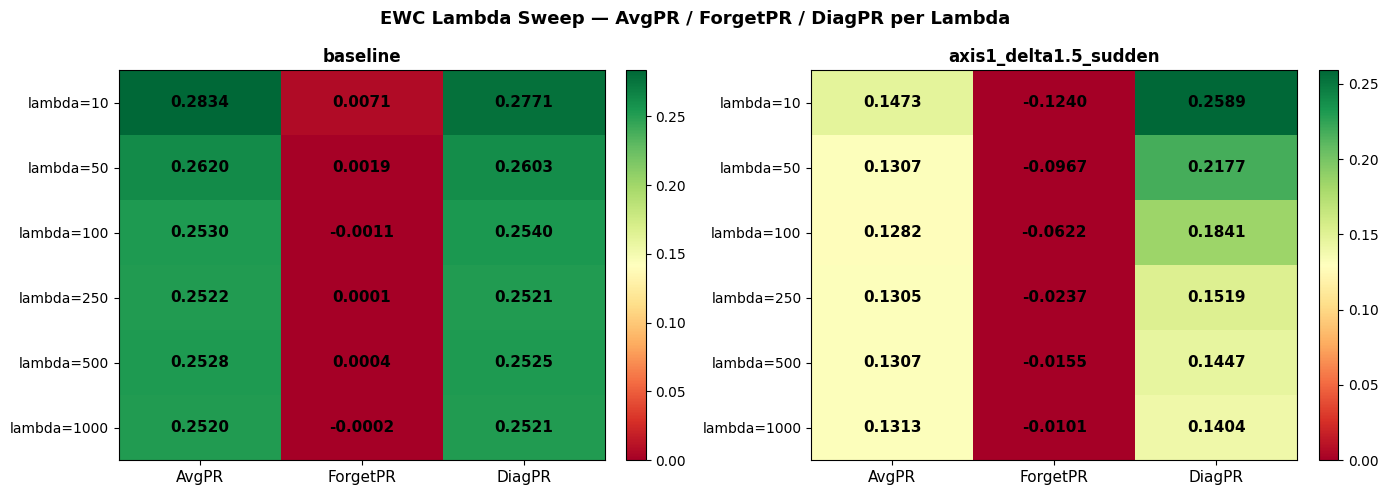

In [5]:
METRICS = [('avg_pr', 'AvgPR'), ('forget_pr', 'ForgetPR'), ('diag_pr', 'DiagPR')]

fig, axes = plt.subplots(1, len(all_results), figsize=(7 * len(all_results), 5))
if len(all_results) == 1:
    axes = [axes]
fig.suptitle('EWC Lambda Sweep — AvgPR / ForgetPR / DiagPR per Lambda', fontsize=13, fontweight='bold')

for ax, (ds_name, res) in zip(axes, all_results.items()):
    mat = np.array([[res[lam][key] for key, _ in METRICS] for lam in LAMBDAS])
    im  = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=mat.max(), aspect='auto')

    for r in range(len(LAMBDAS)):
        for c in range(len(METRICS)):
            ax.text(c, r, f'{mat[r, c]:.4f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='black')

    ax.set_title(ds_name, fontweight='bold')
    ax.set_xticks(range(len(METRICS)))
    ax.set_xticklabels([label for _, label in METRICS], fontsize=11)
    ax.set_yticks(range(len(LAMBDAS)))
    ax.set_yticklabels([f'lambda={lam}' for lam in LAMBDAS], fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
out = PROJECT_ROOT / 'res/Thesis Figures'
out.mkdir(parents=True, exist_ok=True)
plt.savefig(out / 'ewc_lambda_sweep_matrix.png', dpi=150, bbox_inches='tight')
plt.show()